# SNN Online Learning

**Train a spiking neural network using pp-prop**

Spiking Neural Networks (SNNs) process information through discrete spike events, mimicking the communication mechanism of biological neurons. Unlike traditional artificial neural networks that operate on continuous activations, SNNs emphasize the timing and frequency of spikes, making them inherently suited for temporal data processing.

**Online learning** is a natural fit for SNNs because they process inputs sequentially, one time step at a time. Instead of storing the entire computation graph for backpropagation through time (BPTT), online learning algorithms update weight gradients incrementally at each time step. This eliminates the need to unroll the network over the full sequence length, resulting in constant memory usage with respect to sequence length.

In this tutorial, we use `braintrace.pp_prop` (historically exposed as `braintrace.ES_D_RTRL`), an online estimator that factorizes the eligibility trace into input and output components. Its trace memory is **O(B(I+O))** (where B is batch size, I is input dimension, and O is output dimension), subject to the documented model and operator assumptions.

**What you will learn:**

1. Build an SNN model using `brainstate` neurons and `braintrace.nn` layers.
2. Configure online learning with `braintrace.pp_prop`.
3. Accumulate gradients over a spike sequence and update the model.
4. Distinguish the D-RTRL and input/output-factorized trace regimes.

## 1. Setup

First, let us import the required packages. The key components are:
- `brainstate`: provides neuron models (LIF), state management, and JAX-based transformations
- `braintrace`: provides online learning algorithms and ETP-aware neural network layers
- `braintools`: provides initializers, optimizers, surrogate gradient functions, and metrics
- `brainunit`: provides physical units (ms, mV, etc.) for biologically meaningful parameters

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax.numpy as jnp
import brainstate
import braintools
import braintrace
import brainunit as u
import brainpy.state
import matplotlib.pyplot as plt

brainstate.random.seed(31)

## 2. SNN Model

We build a simple recurrent SNN with the following architecture:

1. **Input + Recurrent Projection**: A `braintrace.nn.Linear` layer that projects the concatenation of input spikes and recurrent spikes into the hidden layer. Using `braintrace.nn.Linear` (instead of a plain matrix multiply) marks this projection for participation in online learning via ETP primitives.

2. **LIF Neuron**: A Leaky Integrate-and-Fire neuron from `brainpy.state.LIF`. The LIF neuron integrates its input current, fires a spike when the membrane potential exceeds a threshold, and then resets. We use `braintools.surrogate.ReluGrad()` as the surrogate gradient function for differentiability.

3. **Readout**: A `braintrace.nn.LeakyRateReadout` that applies leaky integration to the recurrent spikes and produces a continuous output signal for classification. This layer is also ETP-aware.

The recurrent connectivity is achieved by concatenating the neuron's own spike output with the external input at each time step.

In [2]:
class LIF_SNN(brainstate.nn.Module):
    """A simple recurrent SNN with LIF neurons for online learning."""

    def __init__(self, n_in, n_rec, n_out, tau_mem=20. * u.ms, tau_out=20. * u.ms):
        super().__init__()

        # Input + recurrent projection (ETP-aware: participates in online learning).
        # Weights are in current units so that ``I * R`` lands in mV inside the LIF
        # neuron (LIF integrates ``-V + I*R``; ``mA * ohm = mV`` matches V_th below).
        self.linear = braintrace.nn.Linear(
            n_in + n_rec, n_rec,
            w_init=braintools.init.KaimingNormal(scale=50., unit=u.mA),
            b_init=braintools.init.ZeroInit(unit=u.mA),
        )

        # LIF neuron with surrogate gradient for differentiability.
        self.neuron = brainpy.state.LIF(
            n_rec,
            tau=tau_mem,
            R=1. * u.ohm,
            V_th=0.1 * u.mV,
            V_reset=0. * u.mV,
            V_rest=0. * u.mV,
            spk_fun=braintools.surrogate.ReluGrad(),
            spk_reset='soft',
        )

        # Readout layer (ETP-aware: participates in online learning).
        self.readout = braintrace.nn.LeakyRateReadout(
            n_rec, n_out,
            tau=tau_out,
            w_init=braintools.init.KaimingNormal(),
        )

    def update(self, spike_input):
        # Concatenate input spikes with recurrent spikes.
        rec_spk = self.neuron.get_spike()
        x = jnp.concatenate([spike_input, rec_spk], axis=-1)

        # Linear projection -> LIF neuron dynamics -> readout.
        spike = self.neuron(self.linear(x))
        return self.readout(spike)

Let us verify that the model can be instantiated and produce output for a single sample.

In [3]:
with brainstate.environ.context(dt=1. * u.ms):
    model = LIF_SNN(n_in=50, n_rec=128, n_out=10)
    brainstate.nn.init_all_states(model)

    # A short structured spike train verifies non-zero network activity.
    test_inputs = brainstate.random.bernoulli(
        0.6, size=(20, 50)
    ).astype(jnp.float32)
    outputs = brainstate.transform.for_loop(model, test_inputs)
    output = outputs[-1]
    print(f"Output shape: {output.shape}")
    print(f"Output values: {output}")
    print(f"Mean |output|: {float(jnp.mean(jnp.abs(outputs))):.4f}")

Output shape: (10,)
Output values: [ -0.73483455 -29.564928    11.474621     5.180525    21.198288
   3.3511796   -3.6710746   -0.11585347  -0.3551005  -11.977058  ]
Mean |output|: 5.3924


## 3. Training with pp-prop on an aligned temporal window

We use `braintrace.pp_prop`, backed by `braintrace.IODimVjpAlgorithm`.
`decay_or_rank` controls the trace approximation: a float in `[0, 1)` is the
exponential-smoothing decay, while an integer at least 1 maps to
`decay = (rank - 1) / (rank + 1)`. The decay is part of the estimator and must
be reported with results.

This workflow trains one sequence at a time, so it needs neither a batch axis
nor state mapping. The learner is compiled from one feature vector, not an
entire temporal sequence. The warm-up mask drives neuron and eligibility states
without scoring the prefix; the returned loss and accuracy both use the same
post-warm-up time steps. `braintrace.D_RTRL` is the parameter-dimensional
alternative; neither estimator is generally gradient-equivalent to BPTT
outside its documented assumptions.


In [4]:
def make_spike_classification_sequences(
    n_updates=80, n_steps=60, n_in=50, n_out=10
):
    """Create class-specific spike sequences without a batch axis."""
    labels = jnp.arange(n_updates, dtype=jnp.int32) % n_out
    channel_class = jnp.arange(n_in) * n_out // n_in
    active = labels[:, None] == channel_class[None, :]
    firing_probability = jnp.where(active, 0.6, 0.0)
    inputs = brainstate.random.bernoulli(
        firing_probability[:, None, :],
        size=(n_updates, n_steps, n_in),
    ).astype(jnp.float32)
    return inputs, labels


def train_snn(input_sequences, targets, n_rec=128, lr=3e-3):
    """Train one recurrent SNN sequence at a time with pp-prop."""
    n_in = input_sequences.shape[-1]
    n_out = int(targets.max()) + 1

    with brainstate.environ.context(dt=1. * u.ms):
        brainstate.random.seed(37)
        model = LIF_SNN(n_in, n_rec, n_out)
        brainstate.nn.init_all_states(model)
        learner = braintrace.pp_prop(model, decay_or_rank=0.5)
        learner.compile_graph(input_sequences[0, 0])

        opt = braintools.optim.Adam(lr)
        opt.register_trainable_weights(learner.param_states)

        warmup = input_sequences.shape[1] // 5
        loss_mask = (
            jnp.arange(input_sequences.shape[1]) >= warmup
        ).astype(jnp.float32)

        @brainstate.transform.jit
        def train_step(inputs, target):
            brainstate.nn.reset_all_states(model)
            learner.reset_state()

            def step_loss(inp):
                output = learner(inp)
                loss = braintools.metric.softmax_cross_entropy_with_integer_labels(
                    output, target
                ).mean()
                return loss, output

            grads, objective, outputs = learner.etrace_grad(
                inputs,
                step_fn=step_loss,
                has_aux=True,
                mask=loss_mask,
                reduction='mean',
                loss_output='scalar',
                return_value=True,
            )
            opt.update(brainstate.nn.clip_grad_norm(grads, 1.0))
            predictions = jnp.argmax(outputs, axis=-1)
            correct = (predictions == target).astype(jnp.float32)
            accuracy = jnp.sum(correct * loss_mask) / jnp.sum(loss_mask)
            return objective, accuracy

        return brainstate.transform.for_loop(
            train_step, input_sequences, targets
        )


Run the fixed-seed sequence updates. The first update is slower because the transformed training step is compiled.


In [5]:
brainstate.random.seed(41)
spike_inputs, spike_targets = make_spike_classification_sequences()
losses, accuracies = train_snn(spike_inputs, spike_targets)
for update in (0, 20, 40, 60, 79):
    print(
        f"Update {update:2d}, Loss: {float(losses[update]):.4f}, "
        f"Accuracy: {float(accuracies[update]):.3f}"
    )


Update  0, Loss: 5.3968, Accuracy: 0.208
Update 20, Loss: 1.1892, Accuracy: 0.500
Update 40, Loss: 0.8719, Accuracy: 0.708
Update 60, Loss: 0.6732, Accuracy: 0.771
Update 79, Loss: 0.1277, Accuracy: 1.000


Plot the masked objective and post-warm-up
accuracy over 80 single-sequence parameter updates. This fixed task is an
optimization smoke check: it can establish finite execution and task-specific
descent, but not pp-prop/BPTT equality or general convergence.


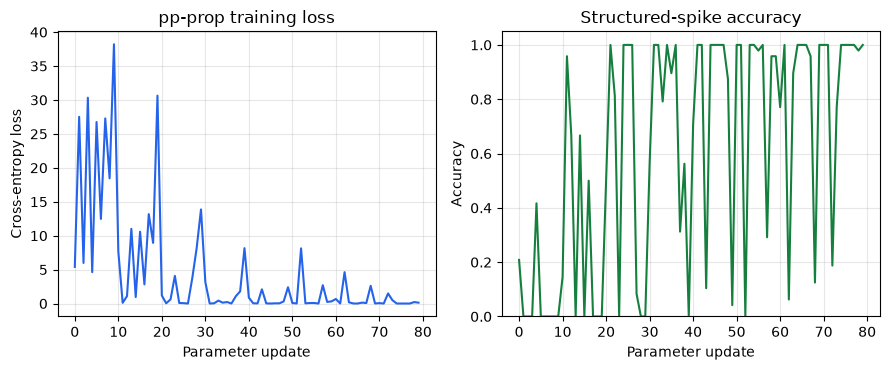

In [6]:
with plt.style.context("default"), plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
    axes[0].plot(losses, color="#2563eb")
    axes[0].set(xlabel="Parameter update", ylabel="Cross-entropy loss")
    axes[0].set_title("pp-prop training loss")
    axes[1].plot(accuracies, color="#15803d")
    axes[1].set(xlabel="Parameter update", ylabel="Accuracy", ylim=(0, 1.05))
    axes[1].set_title("Structured-spike accuracy")
    for axis in axes:
        axis.grid(True, alpha=0.3)
    fig.tight_layout()
plt.show()

## 4. Key differences: D-RTRL vs pp-prop

| Aspect | D-RTRL (`ParamDimVjpAlgorithm`) | pp-prop (`pp_prop`) |
|---|---|---|
| Eligibility trace | Parameter-shaped, diagonal hidden-Jacobian approximation | Input/output-factorized with smoothing |
| Main cost | Grows with traced parameter and hidden dimensions | Grows with retained input/output factors |
| Main approximation | Drops cross-position hidden-Jacobian terms | Drops correlations outside the factorization |
| Appropriate use | Parameter-shaped trace is affordable | Lower trace memory is required and validated |

`decay_or_rank` is part of the pp-prop estimator. Validate either rule with a
finite-window oracle on a reduced version of the intended model before making a
gradient-fidelity claim. See {class}`braintrace.D_RTRL`,
{class}`braintrace.pp_prop`, and {func}`braintrace.compile`.


## 5. Summary

This workflow advances the LIF neuron exactly once per logical time step,
compiles from one time-step input, and evaluates the same post-warm-up window
used by the training objective. Repeated execution is owned by
`brainstate.transform` and `learner.etrace_grad`, not a Python model loop.

Continue with the focused [pp-prop algorithm tutorial](pp_prop.ipynb),
[e-prop](eprop.ipynb), and the [algorithm API reference](../apis/algorithms.rst).
